# Insurance Claims Fraud Detection Analytics


#### Business Problem
Insurance fraud is one of the leading causes of financial losses in the insurance industry. Processing every claim with the same level of scrutiny is both time-consuming and expensive. Therefore, insurance companies require data-driven methods to identify suspicious claims and prioritize investigations efficiently.

This project analyzes historical insurance claim data to uncover patterns associated with fraudulent behavior and generate actionable business insights that can support fraud detection strategies.

#### Project Objectives
- Which customer demographics are more likely to be associated with fraudulent claims?
- Which policy and claim characteristics indicate a higher fraud risk?
- How do claim amount, incident type, and policy history influence fraudulent activity?
- What operational recommendations can help reduce fraudulent claim payouts?

#### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

#### Dataset Overview

The dataset contains information related to:
- Customer Demographics
- Insurance Policies
- Claim Details
- Incident Characteristics
- Claim Types and Amounts
- Policy History
- Fraud Indicators

#### Project Workflow
- Data Understanding
- Data Cleaning & Preprocessing
- Exploratory Data Analysis
- Fraud Pattern Analysis
- Business Insights
- Recommendations

## Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import scipy.stats as stats

# Supress unnecessary warnings for cleaner notebook output
warnings.filterwarnings('ignore')

## Loading & Integrating Datasets

The insurance data is stored across multiple relational tables containing customer demographics and insurance claim records. These datasets are loaded individually and merged using the customer identifier to create a unified analytical dataset for subsequent analysis.

In [2]:
# Changed the current working directory of python to a specified path
os.chdir('C:\\Users\\gulya\\OneDrive\\Desktop\\Python Class\\assignment\\Python Foundation Case Study 3 - Insurance Claims Case Study\\Case Study 3 - Insurance Claims Case Study')

# Load Datasets
claims_df=pd.read_csv('claims.csv')
cust_df=pd.read_csv('cust_demographics.csv')

# Display dataset dimensions
print('Claims Dataset:',claims_df.shape)
print('Customer Dataset:',cust_df.shape)

# Merge claims and customer information
insurance_df=pd.merge(left=claims_df,right=cust_df,left_on='customer_id',right_on='CUST_ID',how='left')

# Remove duplicate key column
insurance_df.drop(labels='CUST_ID',axis=1,inplace=True)

# Verify merged Dataset
print('Merged Dataset:',insurance_df.shape)
insurance_df.head()

Claims Dataset: (1100, 10)
Customer Dataset: (1085, 6)
Merged Dataset: (1100, 15)


,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,Female,11-Mar-84,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,Female,01-May-86,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No,Male,13-May-77,NV,956-871-8691,Gold


## Understanding the Dataset

#### Dataset Shape

In [3]:
print(f"Dataset Shape : {insurance_df.shape[0]} rows × {insurance_df.shape[1]} columns")

Dataset Shape : 1100 rows × 15 columns


#### Dataset Preview

In [4]:
insurance_df.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No,Female,12-Jan-79,VT,789-916-8172,Platinum
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No,Female,13-Jan-70,ME,265-543-1264,Silver
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes,Female,11-Mar-84,TN,798-631-4758,Silver
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No,Female,01-May-86,MA,413-187-7945,Silver
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No,Male,13-May-77,NV,956-871-8691,Gold


#### Dataset Structure Overview

In [5]:
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1100 non-null   int64  
 1   customer_id          1100 non-null   int64  
 2   incident_cause       1100 non-null   object 
 3   claim_date           1100 non-null   object 
 4   claim_area           1100 non-null   object 
 5   police_report        1100 non-null   object 
 6   claim_type           1100 non-null   object 
 7   claim_amount         1035 non-null   object 
 8   total_policy_claims  1090 non-null   float64
 9   fraudulent           1100 non-null   object 
 10  gender               1085 non-null   object 
 11  DateOfBirth          1085 non-null   object 
 12  State                1085 non-null   object 
 13  Contact              1085 non-null   object 
 14  Segment              1085 non-null   object 
dtypes: float64(1), int64(2), object(12)
me

##### Initial Data Quality Assessment

- claim_amount is stored as object instead of numeric data type
- The claim_date and DateOfBirth columns are stored as objects and must be converted to datetime format to enable time-based analysis and age calculation.
- Missing values are present in seven variables (claim_amount, total_policy_claims, gender, DateOfBirth, State, Contact, and Segment) and will require appropriate treatment before performing advanced analysis.

#### Claim Amount investigation

In [6]:
insurance_df.claim_amount.sample(10)

602      $2980
654     $21920
699      $3358
484     $25730
341      $1450
888     $34780
1005     $1350
696      $1630
851      $2150
1040    $28520
Name: claim_amount, dtype: object

The claim_amount column is stored as an object due to the presence of currency symbols and requires conversion to a numeric data type for quantitative analysis.

#### Converting Claim Amount

In [7]:
insurance_df['claim_amount']=insurance_df.claim_amount.str.replace('$','').astype('float')
print(insurance_df.claim_amount.dtypes)

float64


#### Validating Date Formats

In [8]:
insurance_df.sample(5)

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
743,30927069,15681024,Natural causes,03/22/2017,Auto,No,Material and injury,14220.0,1.0,No,Female,28-Nov-83,AL,216-539-3569,Silver
267,86070727,97038550,Other driver error,02/22/2018,Home,Unknown,Material and injury,16790.0,1.0,No,Female,08-Oct-73,FL,963-613-5369,Platinum
313,2980099,28901669,Crime,02/02/2018,Auto,Yes,Injury only,35178.5,1.0,Yes,Female,28-May-81,MT,798-435-4862,Silver
933,93697901,91322083,Other causes,05/15/2017,Auto,Unknown,Material and injury,17370.0,3.0,No,Female,28-Apr-83,CO,425-138-4538,Gold
213,3883874,16868327,Driver error,01/14/2017,Auto,No,Material only,1400.0,1.0,No,Male,14-Feb-68,VT,426-293-4958,Silver


##### Observations

- A sample inspection indicates that the values in both claim_date and DateOfBirth follow a consistent date format.
- No inconsistencies were observed in the sampled records that would prevent conversion to the datetime data type.

#### Datetime Conversion

In [9]:
insurance_df['claim_date']=pd.to_datetime(insurance_df['claim_date'],format='%m/%d/%Y')
insurance_df['DateOfBirth']=pd.to_datetime(insurance_df['DateOfBirth'],format='%d-%b-%y')
print(insurance_df[['claim_date','DateOfBirth']].dtypes)

claim_date     datetime64[ns]
DateOfBirth    datetime64[ns]
dtype: object


#### Summary Statistics

In [10]:
insurance_df.describe().T

,count,mean,min,25%,50%,75%,max,std
claim_id,1100.0,48838190.052727,26832.0,23815805.0,48539331.0,74074466.0,99775483.0,29188059.567557
customer_id,1100.0,50799544.012727,154557.0,26479506.5,49790067.0,76019781.25,99961993.0,28477268.13232
claim_date,1100,2017-11-26 09:08:30.545454592,2017-01-01 00:00:00,2017-06-04 00:00:00,2017-11-27 00:00:00,2018-05-14 00:00:00,2018-10-30 00:00:00,NaN
claim_amount,1035.0,12442.125121,1000.0,1870.0,2740.0,24300.0,48150.5,13766.391982
total_policy_claims,1090.0,1.591743,1.0,1.0,1.0,2.0,8.0,1.147251
DateOfBirth,1085,2002-10-05 12:20:34.285714176,1969-01-01 00:00:00,1979-05-09 00:00:00,1989-06-11 00:00:00,1999-02-20 00:00:00,2068-12-19 00:00:00,NaN


In [11]:
insurance_df.describe(include='object').T

,count,unique,top,freq
incident_cause,1100,5,Other causes,290
claim_area,1100,2,Auto,985
police_report,1100,3,No,630
claim_type,1100,3,Material only,663
fraudulent,1100,2,No,846
gender,1085,2,Male,556
State,1085,50,NY,31
Contact,1085,1078,743-569-4783,2
Segment,1085,3,Gold,375


#### Initial Data Quality & Exploratory Observations

1. Data Quality Issues
- Missing values are present in claim_amount, total_policy_claims, gender, DateOfBirth, State, Contact, and Segment. Appropriate missing value treatment will be performed before further analysis.
- The DateOfBirth column contains future dates, indicating data quality issues that must be corrected before calculating customer age.

2. Claim Characteristics

- The distribution of claim_amount is highly right-skewed, indicating that a small number of high-value claims substantially increase the average claim amount.
- Several unusually large claim amounts suggest the presence of potential outliers that may disproportionately influence statistical measures such as the mean.

3. Customer Behaviour
- Most customers have only one or two previous policy claims.
- A small group of customers has a relatively high claim frequency and may represent a higher-risk customer segment.

4. Fraud Distribution
- Most insurance claims are classified as non-fraudulent, indicating a class imbalance that should be considered during fraud analysis.

5. Business Insights for Further Analysis
- Auto-related claims account for the majority of insurance claims; subsequent analyses may therefore be influenced by this category.
- A large proportion of claims do not involve police reports. The relationship between police reports and fraudulent claims should be investigated further.
- Material-only incidents represent the most common claim type. Additional analysis will determine whether claim type influences claim severity or fraud occurrence.
- "Other causes" is the most frequently reported incident category and will be analyzed further to evaluate its association with claim costs and fraudulent activity.

## Data Quality Assessment

Before performing exploratory analysis, it is essential to assess the quality of the dataset. This section evaluates missing values, duplicate records, key integrity, invalid values, and potential outliers to ensure the data is accurate, consistent, and suitable for analysis.

#### Missing Values

In [12]:
missing_summary=pd.DataFrame({'Missing Values': insurance_df.isna().sum(),'Missing Percentage':((insurance_df.isna().sum()/len(insurance_df))*100)\
    .round(2)})

missing_summary[missing_summary['Missing Values']>0]

,Missing Values,Missing Percentage
claim_amount,65,5.91
total_policy_claims,10,0.91
gender,15,1.36
DateOfBirth,15,1.36
State,15,1.36
Contact,15,1.36
Segment,15,1.36


##### Observations

- Missing values are present in seven variables.
- The proportion of missing values was evaluated to determine an appropriate imputation strategy.
- Numerical and categorical variables will be handled separately to preserve data integrity.

#### Duplicate Records

In [13]:
insurance_df.duplicated().sum()

np.int64(0)

##### Observations

- No duplicate records were identified, indicating that each row represents a unique insurance claim.

#### Key Uniqueness

In [14]:
insurance_df.claim_id.is_unique

True

##### Observations

The number of unique claim_id values matches the total number of records, confirming that claim_id uniquely identifies each insurance claim.

#### Checking Categorical Discrepancies

In [15]:
insurance_df.select_dtypes(include=['object','category']).columns

Index(['incident_cause', 'claim_area', 'police_report', 'claim_type',
       'fraudulent', 'gender', 'State', 'Contact', 'Segment'],
      dtype='object')

In [16]:
categorical_columns=['incident_cause', 'claim_area', 'police_report', 'claim_type', 'fraudulent', 'gender', 'State', 'Segment']

for i in categorical_columns:
    print(insurance_df[i].value_counts())
    print('\n')

incident_cause
Other causes          290
Driver error          262
Other driver error    249
Natural causes        189
Crime                 110
Name: count, dtype: int64


claim_area
Auto    985
Home    115
Name: count, dtype: int64


police_report
No         630
Unknown    300
Yes        170
Name: count, dtype: int64


claim_type
Material only          663
Material and injury    241
Injury only            196
Name: count, dtype: int64


fraudulent
No     846
Yes    254
Name: count, dtype: int64


gender
Male      556
Female    529
Name: count, dtype: int64


State
NY    31
AR    29
DE    29
AL    28
ME    28
ND    27
ID    27
TN    27
RI    26
IA    26
NV    26
MA    26
SD    25
CO    25
CT    25
FL    24
NC    24
WI    23
IL    23
TX    22
IN    22
OH    22
MO    22
VT    22
NE    21
PA    21
MD    21
OK    21
AK    20
WV    20
MT    20
LA    20
NM    19
WA    19
GA    19
KS    19
SC    19
NH    18
MI    18
VA    18
UT    18
HI    17
CA    17
MN    17
NJ    17
MS    17
WY    17
AZ  

##### Observations

- Category labels appear consistent across the dataset.
- No spelling inconsistencies, unexpected categories, or formatting issues were identified during inspection.
- The categorical variables are suitable for subsequent analysis without additional standardization.

#### Business Rule Validation

In [17]:
print('Future DOB Records:', insurance_df[insurance_df.DateOfBirth > pd.Timestamp.today()].shape[0])
print('Negative Claim Amounts:', insurance_df[insurance_df.claim_amount<0].shape[0])
print('Negative Previous Claims', insurance_df[insurance_df.total_policy_claims<0].shape[0])
print('Future Claim Dates:', insurance_df[insurance_df.claim_date>pd.Timestamp.today()].shape[0])

Future DOB Records: 245
Negative Claim Amounts: 0
Negative Previous Claims 0
Future Claim Dates: 0


##### Observations

- Business rule validation identified 245 records with future dates of birth, indicating a data quality issue that must be corrected before calculating customer age.
- No negative claim amounts, negative previous claim counts, or future claim dates were identified, suggesting that these variables are logically consistent with expected business rules.
- Apart from the DateOfBirth anomaly, no major business rule violations were detected in the dataset.

#### Outlier Assessment

Outliers were evaluated to determine whether they represent genuine business behaviour or erroneous observations. In fraud detection problems, unusually high claim values or claim frequencies may indicate potentially fraudulent activity and therefore should be investigated before deciding whether to remove them.

In [18]:
insurance_df.select_dtypes(include='number').columns

Index(['claim_id', 'customer_id', 'claim_amount', 'total_policy_claims'], dtype='object')

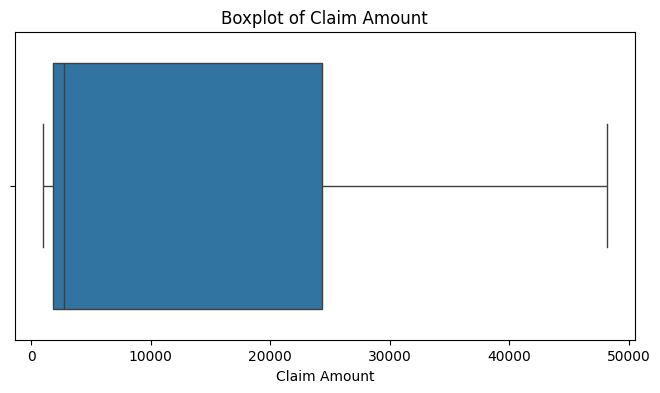

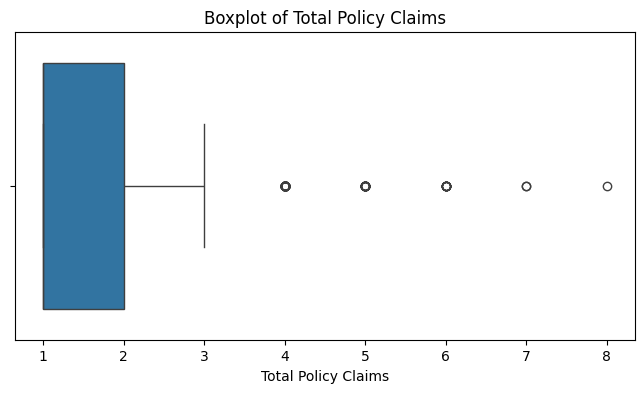

In [19]:
numerical_columns= ['claim_amount', 'total_policy_claims']

for i in numerical_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=insurance_df,x=i)
    plt.title(f"Boxplot of {i.replace('_', ' ').title()}")
    plt.xlabel(f"{i.replace('_',' ').title()}")
    plt.show()

In [20]:
# Quantifying Outliers

for i in numerical_columns:
    Q1 = insurance_df[i].quantile(0.25)
    Q3 = insurance_df[i].quantile(0.75)
    IQR = Q3 - Q1
    outliers = insurance_df[(insurance_df[i] < Q1 - 1.5 * IQR) | (insurance_df[i] > Q3 + 1.5 * IQR)]
    print(f"{i}: {outliers.shape[0]}")

claim_amount: 0
total_policy_claims: 101


##### Observations

- The claim_amount distribution contains several high-value observations; however, these represent genuine insurance claims rather than obvious data entry errors.
- The total_policy_claims variable also contains several extreme observations corresponding to customers with unusually high claim frequencies.
- Given the objective of fraud detection, these observations may represent high-risk customers rather than invalid records. Therefore, the identified outliers have been retained for subsequent analysis instead of being removed.

#### Data Quality Summary

- Missing values were identified in seven variables: claim_amount, total_policy_claims, gender, DateOfBirth, State, Contact, and Segment. Appropriate imputation strategies will be applied during the data cleaning phase.
- No duplicate records were detected, and the claim_id column was confirmed to uniquely identify each insurance claim, ensuring data integrity.
- Categorical variables were reviewed and found to contain consistent category labels with no significant formatting or spelling discrepancies.
- Business rule validation identified 245 records with future dates of birth, indicating a data quality issue that must be corrected before deriving customer age. No negative claim amounts, negative previous claim counts, or future claim dates were detected.
- Statistical outlier analysis identified extreme observations in total_policy_claims. These records appear to represent customers with unusually high claim frequencies rather than data entry errors. Since the objective of this project is fraud detection, these observations have been retained for further analysis as they may provide valuable insights into high-risk customer behaviour.

Overall, the dataset exhibits good structural quality with no duplicate records or major consistency issues. The identified data quality concerns primarily relate to missing values and invalid dates, which will be addressed in the subsequent data cleaning stage before proceeding with exploratory analysis.

## Data Cleaning

#### Missing Value Treatment

In [21]:
# Checking Percentage of Missing Values

missing_summary[missing_summary['Missing Values']>0]

,Missing Values,Missing Percentage
claim_amount,65,5.91
total_policy_claims,10,0.91
gender,15,1.36
DateOfBirth,15,1.36
State,15,1.36
Contact,15,1.36
Segment,15,1.36


##### Observations

- claim_amount contains approximately 5.9% missing values. Since the distribution is positively skewed, missing values will be imputed using the median to reduce the influence of extreme observations.
- total_policy_claims contains less than 1% missing values and will also be imputed using the median to preserve existing records.
- gender, DateOfBirth, State, Contact, and Segment exhibit identical missing percentages, suggesting that the missing values originate from the same customer records rather than occurring independently.

In [22]:
# Investigating Missing Customer Profile Records

insurance_df[insurance_df['gender'].isna()]

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,gender,DateOfBirth,State,Contact,Segment
1085,5829074,2379897,Other causes,2018-07-20,Auto,No,Material only,2080.0,1.0,No,NaN,NaT,NaN,NaN,NaN
1086,12632133,49290530,Natural causes,2018-10-30,Auto,No,Material only,2875.0,1.0,Yes,NaN,NaT,NaN,NaN,NaN
1087,45052103,55466148,Driver error,2017-12-03,Auto,No,Injury only,29010.0,1.0,No,NaN,NaT,NaN,NaN,NaN
1088,87003624,99120304,Other causes,2017-03-22,Auto,No,Material only,1710.0,1.0,No,NaN,NaT,NaN,NaN,NaN
1089,1680169,65061027,Natural causes,2017-05-02,Auto,Unknown,Material only,1030.0,4.0,No,NaN,NaT,NaN,NaN,NaN
1090,56626640,82584690,Other driver error,2017-08-24,Auto,Unknown,Material only,2288.5,1.0,Yes,NaN,NaT,NaN,NaN,NaN
1091,7280558,40349009,Crime,2017-10-17,Auto,No,Material only,3346.5,3.0,Yes,NaN,NaT,NaN,NaN,NaN
1092,74995596,55765343,Crime,2018-06-30,Auto,Unknown,Material only,1805.5,1.0,Yes,NaN,NaT,NaN,NaN,NaN
1093,8475725,75409818,Other causes,2018-07-07,Auto,No,Material only,1610.0,3.0,No,NaN,NaT,NaN,NaN,NaN
1094,33194240,18332683,Other causes,2017-11-13,Auto,Yes,Material and injury,24850.0,1.0,No,NaN,NaT,NaN,NaN,NaN


In [23]:
print('Rows with missing customer profile information:',len(insurance_df[insurance_df['gender'].isna()]))

Rows with missing customer profile information: 15


##### Observations

- Missing values in gender, DateOfBirth, State, Contact, and Segment occur within the same customer records, indicating incomplete customer profiles rather than independent missing values.
- Since DateOfBirth and Contact are customer-specific attributes, reliable imputation is not feasible and may introduce artificial information into the dataset.
- These incomplete records account for only 1.36% of the dataset and can therefore be removed with minimal impact on the overall representativeness of the data.

In [24]:
# Imputing Missing Values in Continuous Columns

for i in numerical_columns:
    insurance_df[i]=insurance_df[i].fillna(insurance_df[i].median())

In [25]:
# Verifying Imputation

insurance_df[numerical_columns].isna().sum()

claim_amount           0
total_policy_claims    0
dtype: int64

In [26]:
# Removing Incomplete Customer Profiles

insurance_df.dropna(inplace=True)

In [27]:
# Validation

print('Dataset Shape:',insurance_df.shape[0])
insurance_df.isna().sum()

Dataset Shape: 1085


claim_id               0
customer_id            0
incident_cause         0
claim_date             0
claim_area             0
police_report          0
claim_type             0
claim_amount           0
total_policy_claims    0
fraudulent             0
gender                 0
DateOfBirth            0
State                  0
Contact                0
Segment                0
dtype: int64

#### Correcting Invalid Date of Birth Values

In [28]:
# Identifying Records with Future Dates of Birth

print('Records with future DOB:',len(insurance_df[insurance_df['DateOfBirth'] > pd.Timestamp.today()]))
insurance_df.loc[insurance_df['DateOfBirth'] > pd.Timestamp.today(), ['customer_id', 'DateOfBirth']].sample(10)

Records with future DOB: 245


,customer_id,DateOfBirth
990,86164274,2062-12-28
642,88200222,2066-09-15
193,51503228,2060-07-12
356,49078798,2065-05-07
643,88878373,2066-07-05
1013,69623124,2067-11-25
79,95221640,2067-07-13
458,44643917,2068-12-19
409,95002919,2064-04-15
927,95628948,2060-09-22


In [29]:
# Investigating the Pattern 

insurance_df.loc[insurance_df['DateOfBirth'] > pd.Timestamp.today(), 'DateOfBirth'].dt.year.value_counts()

DateOfBirth
2067    32
2066    30
2064    30
2060    30
2063    27
2065    27
2062    26
2068    24
2061    19
Name: count, dtype: int64

##### Observations

- A total of 245 customer records contain future dates of birth.
- All affected dates fall between 2060 and 2068, indicating a systematic pattern rather than isolated data entry errors.
- The observed years correspond to the common two-digit year conversion rule, where years 00–68 are interpreted as 2000–2068 instead of 1900–1968.
- This suggests that the invalid dates were introduced during data import or system migration due to incorrect century assignment.
- Since the underlying issue is systematic, the affected records can be corrected by subtracting 100 years from the invalid birth dates while preserving the original day and month components.

In [30]:
# Correcting the Date Values

insurance_df.loc[insurance_df['DateOfBirth'] > pd.Timestamp.today(), 'DateOfBirth']=\
insurance_df.loc[insurance_df['DateOfBirth'] > pd.Timestamp.today(), 'DateOfBirth'] - pd.DateOffset(years=100)

In [31]:
# Validation

print('Remaining Future DOB Records:',(insurance_df.DateOfBirth > pd.Timestamp.today()).sum())

Remaining Future DOB Records: 0


#### Column Name Standardization

To improve code readability and maintain a consistent naming convention throughout the analysis, columns with inconsistent capitalization were renamed using lowercase snake_case formatting. Columns already following the naming convention were retained without modification.

In [32]:
insurance_df.columns

Index(['claim_id', 'customer_id', 'incident_cause', 'claim_date', 'claim_area',
       'police_report', 'claim_type', 'claim_amount', 'total_policy_claims',
       'fraudulent', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment'],
      dtype='object')

In [33]:
# Standardizing Inconsistent Column Names

insurance_df.rename({'DateOfBirth':'date_of_birth','State':'state','Contact':'contact','Segment':'segment'},axis=1,inplace=True)

In [34]:
insurance_df.columns

Index(['claim_id', 'customer_id', 'incident_cause', 'claim_date', 'claim_area',
       'police_report', 'claim_type', 'claim_amount', 'total_policy_claims',
       'fraudulent', 'gender', 'date_of_birth', 'state', 'contact', 'segment'],
      dtype='object')

#### Data Cleaning Summary

- Missing values were systematically assessed based on their proportion, variable type, and business relevance.
- Missing values in claim_amount and total_policy_claims were imputed using the median to preserve the distribution of skewed numerical variables.
- Records containing incomplete customer profile information (gender, date_of_birth, state, contact, and segment) were removed, as reliable imputation for customer-specific attributes was not feasible.
- A total of 245 invalid future dates of birth were identified. Investigation revealed a systematic century assignment issue, and the affected records were corrected by adjusting the year component by 100 years.
- Selected column names were standardized to improve naming consistency and code readability while preserving the original schema where appropriate.
- Validation confirmed that all missing values and invalid dates were successfully resolved, resulting in a clean, consistent, and analysis-ready dataset suitable for exploratory analysis and fraud pattern identification.

## Feature Engineering

#### Customer Age

Customer age is derived using the customer's date of birth and claim date. Age is an important demographic variable that can help identify whether fraud patterns vary across different age groups.

In [35]:
# Creating Customer Age

insurance_df['age']=(insurance_df.claim_date - insurance_df.date_of_birth).dt.days//365.25

In [36]:
# Validation

insurance_df.age.describe()

count    1085.000000
mean       37.212903
std        11.651529
min        17.000000
25%        27.000000
50%        37.000000
75%        47.000000
max        58.000000
Name: age, dtype: float64

#### Age Groups

Customers are grouped into meaningful age categories to simplify demographic analysis and enable comparisons of claim behaviour across different stages of life.

In [37]:
# Creating Age Groups

insurance_df['age_group']=pd.cut(x=insurance_df.age,bins=[0,25,35,45,55,65,100],labels=['<25','25-35','35-45','45-55','55-65','65+'])

In [38]:
# Validation

insurance_df["age_group"].value_counts().sort_index()

age_group
<25      237
25-35    264
35-45    257
45-55    282
55-65     45
65+        0
Name: count, dtype: int64

#### Claim Months

The claim month is extracted from the claim date to support seasonal trend analysis and identify whether fraudulent claims exhibit temporal patterns throughout the year.

In [39]:
insurance_df['claim_month']=insurance_df.claim_date.dt.month_name()

In [40]:
# Validation

insurance_df["claim_month"].value_counts()

claim_month
October      122
March        111
July         106
January      105
April        105
June          93
May           93
February      91
August        89
September     78
December      48
November      44
Name: count, dtype: int64

## Final Dataset Validation

Before proceeding to exploratory data analysis, the cleaned dataset is validated to ensure that all preprocessing steps have been successfully completed and that the data is suitable for analysis.

In [41]:
# Dataset Overview after preprocessing

insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1085 entries, 0 to 1084
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   claim_id             1085 non-null   int64         
 1   customer_id          1085 non-null   int64         
 2   incident_cause       1085 non-null   object        
 3   claim_date           1085 non-null   datetime64[ns]
 4   claim_area           1085 non-null   object        
 5   police_report        1085 non-null   object        
 6   claim_type           1085 non-null   object        
 7   claim_amount         1085 non-null   float64       
 8   total_policy_claims  1085 non-null   float64       
 9   fraudulent           1085 non-null   object        
 10  gender               1085 non-null   object        
 11  date_of_birth        1085 non-null   datetime64[ns]
 12  state                1085 non-null   object        
 13  contact              1085 non-null   o

In [42]:
# Validating missing values and duplicate records

print("Missing Values:\n")
print(insurance_df.isna().sum())

print("\nDuplicate Records:", insurance_df.duplicated().sum())

Missing Values:

claim_id               0
customer_id            0
incident_cause         0
claim_date             0
claim_area             0
police_report          0
claim_type             0
claim_amount           0
total_policy_claims    0
fraudulent             0
gender                 0
date_of_birth          0
state                  0
contact                0
segment                0
age                    0
age_group              0
claim_month            0
dtype: int64

Duplicate Records: 0


In [43]:
# Summary statistics of cleaned numerical variables

insurance_df.describe().T

,count,mean,min,25%,50%,75%,max,std
claim_id,1085.0,48915528.400922,26832.0,24046062.0,48559754.0,74043997.0,99775483.0,29128181.617819
customer_id,1085.0,50767904.341935,154557.0,26450621.0,49759488.0,76093960.0,99961993.0,28496245.372373
claim_date,1085,2017-11-26 01:03:42.304147456,2017-01-01 00:00:00,2017-06-04 00:00:00,2017-11-27 00:00:00,2018-05-14 00:00:00,2018-10-30 00:00:00,NaN
claim_amount,1085.0,11884.917051,1000.0,1943.5,2740.0,22850.0,48150.5,13561.73112
total_policy_claims,1085.0,1.581567,1.0,1.0,1.0,2.0,8.0,1.142936
date_of_birth,1085,1980-03-06 22:24:26.543778816,1960-01-16 00:00:00,1969-09-17 00:00:00,1980-05-31 00:00:00,1990-04-11 00:00:00,1999-12-27 00:00:00,NaN
age,1085.0,37.212903,17.0,27.0,37.0,47.0,58.0,11.651529


##### Observations

- All variables now possess appropriate data types for analysis.
- No missing values remain in the cleaned dataset.
- No duplicate records are present.
- Numerical variables exhibit valid summary statistics following data cleaning and feature engineering.
- The dataset is fully prepared for exploratory data analysis.

## Exploratory Data Analysis (EDA)

The objective of this analysis is to understand the characteristics of insurance claims, explore customer and claim behaviour, identify factors associated with fraudulent claims, and generate data-driven insights that support fraud detection and claims management.

#### Analysis Roadmap
The exploratory analysis is organized into the following stages:

1. Business Overview
   - High-level fraud indicators
   - Overall claims portfolio

2. Univariate Analysis
   - Distribution of numerical variables
   - Distribution of categorical variables

3. Bivariate Analysis
   - Fraud analysis across customer and claim characteristics
   - Claim amount analysis across different categories

4. Correlation Analysis
   - Relationships among numerical variables

5. Hypothesis Testing
   - Statistical validation of key business findings
   
6. Key Insights

7. Business Recommendations

### Business Overview & Fraud Baseline

This section provides a high-level summary of the insurance claims portfolio. These indicators establish the overall fraud landscape and provide business context before conducting detailed exploratory analysis.

In [44]:
business_overview = pd.DataFrame({"Metric": ["Total Claims", "Fraudulent Claims", "Fraud Rate (%)", "Total Claim Amount ($)",\
                                             "Total Fraud Claim Amount ($)"], \
                                  "Value": [ insurance_df["claim_id"].nunique(),\
                                            (insurance_df["fraudulent"] == "Yes").sum(),\
                                             round((insurance_df["fraudulent"] == "Yes").mean() * 100, 2),\
                                             round(insurance_df.claim_amount.sum(), 2),\
                                             round(insurance_df.loc[insurance_df["fraudulent"] == "Yes","claim_amount"].sum(), 2)]})

business_overview

,Metric,Value
0,Total Claims,1085.00
1,Fraudulent Claims,247.00
2,Fraud Rate (%),22.76
3,Total Claim Amount ($),12895135.00
4,Total Fraud Claim Amount ($),3051875.00


##### Observations

- The dataset contains 1,085 insurance claims, providing a sufficient sample for analyzing claim characteristics and fraudulent behaviour.
- Fraudulent claims account for 22.76% of all claims, indicating that while fraud represents a minority of cases, it remains a significant operational and financial concern for the insurer.
- Fraudulent claims collectively amount to approximately 3.05 million, highlighting the substantial financial exposure associated with insurance fraud.
- The average fraudulent claim amount is approximately $12,356 per claim, suggesting that fraudulent cases involve considerable monetary value and should be prioritized for effective detection and investigation.
- The subsequent analysis will focus on identifying customer, policy, and claim characteristics that distinguish fraudulent claims from legitimate ones.

### Preparing Variables for Analysis

To ensure appropriate analytical techniques are applied, variables are grouped into numerical and categorical categories.

In [45]:
print(insurance_df.select_dtypes(include=['object','category']).columns)
print(insurance_df.select_dtypes(include='number').columns)

Index(['incident_cause', 'claim_area', 'police_report', 'claim_type',
       'fraudulent', 'gender', 'state', 'contact', 'segment', 'age_group',
       'claim_month'],
      dtype='object')
Index(['claim_id', 'customer_id', 'claim_amount', 'total_policy_claims',
       'age'],
      dtype='object')


In [46]:
cat_df=insurance_df[['incident_cause','claim_area','police_report','claim_type','fraudulent','gender','state','segment','age_group','claim_month']]
cont_df=insurance_df[['claim_amount','total_policy_claims','age']]

In [47]:
# Validation

print(f"Categorical Variables: {len(cat_df)}")
print(f"Numerical Variables: {len(cont_df)}")

Categorical Variables: 1085
Numerical Variables: 1085


### Univariate Analysis

#### Numerical Variable Analysis

The distribution of numerical variables is examined using descriptive statistics and histograms to understand their spread, central tendency, and distribution patterns.

In [48]:
insurance_df[['claim_amount','total_policy_claims','age']].describe().T

,count,mean,std,min,25%,50%,75%,max
claim_amount,1085.0,11884.917051,13561.731120,1000.0,1943.5,2740.0,22850.0,48150.5
total_policy_claims,1085.0,1.581567,1.142936,1.0,1.0,1.0,2.0,8.0
age,1085.0,37.212903,11.651529,17.0,27.0,37.0,47.0,58.0


#### Distribution of Numerical Variables

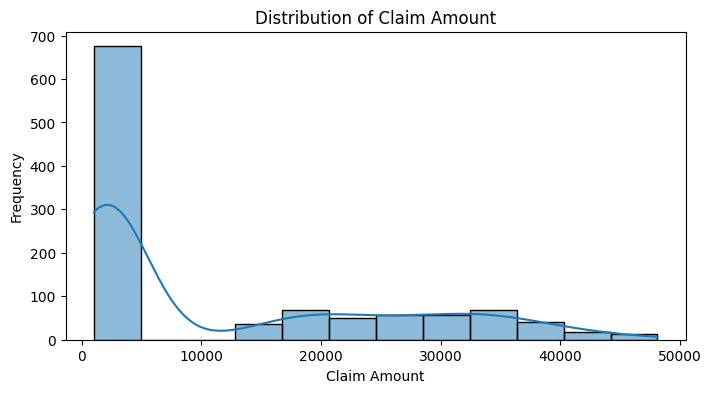

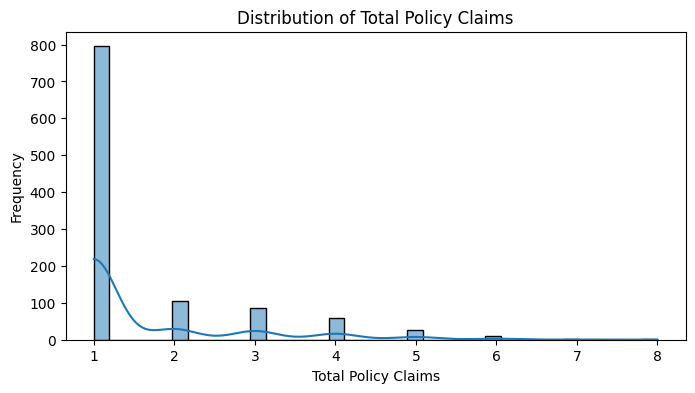

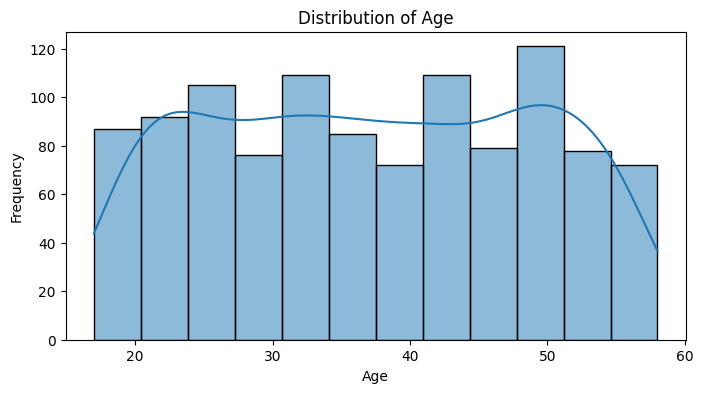

In [49]:
for i in cont_df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(data=insurance_df,x=i,kde=True)
    plt.title(f"Distribution of {i.replace('_',' ').title()}")
    plt.ylabel('Frequency')
    plt.xlabel(f"{i.replace('_',' ').title()}")
    plt.show()

##### Observations

- Claim amounts exhibit substantial variability and a positively skewed distribution, indicating that while most claims involve relatively lower payout amounts, a small number of high-value claims contribute disproportionately to the insurer's financial exposure.
- The distribution of previous policy claims is highly right-skewed, suggesting that most customers have limited claim histories, whereas a small subset of policyholders demonstrates repeated claim activity and may represent a higher-risk segment for further investigation.
- Customer ages are predominantly concentrated between 17 and 58 years, indicating that the claims portfolio is largely composed of working-age policyholders. This provides adequate representation for evaluating the relationship between age and fraudulent claim behaviour.
- The observed skewness in claim amount and previous policy claims suggests that subsequent analyses should consider distribution characteristics when interpreting relationships with fraudulent claims.

#### Categorical Variable Analysis

The categorical variables are analyzed using frequency distributions and count plots to understand the composition of the insurance claims portfolio and identify dominant categories before exploring their relationship with fraudulent claims.

#### Frequency Distribution

In [50]:
# Frequency Distribution (all categorical variables except state)

for i in cat_df[['incident_cause', 'claim_area', 'police_report', 'claim_type', 'fraudulent', 'gender', 'segment']]:
    print(round(cat_df[i].value_counts(normalize=True)*100,2))
    print('\n')

incident_cause
Other causes          26.27
Driver error          24.06
Other driver error    22.58
Natural causes        17.14
Crime                  9.95
Name: proportion, dtype: float64


claim_area
Auto    89.4
Home    10.6
Name: proportion, dtype: float64


police_report
No         57.24
Unknown    27.28
Yes        15.48
Name: proportion, dtype: float64


claim_type
Material only          60.18
Material and injury    21.84
Injury only            17.97
Name: proportion, dtype: float64


fraudulent
No     77.24
Yes    22.76
Name: proportion, dtype: float64


gender
Male      51.24
Female    48.76
Name: proportion, dtype: float64


segment
Gold        34.56
Platinum    33.36
Silver      32.07
Name: proportion, dtype: float64




In [51]:
# Top 10 States by Claim Volume

round(cat_df.state.value_counts(normalize=True)*100,2).head(10)

state
NY    2.86
AR    2.67
DE    2.67
AL    2.58
ME    2.58
ND    2.49
ID    2.49
TN    2.49
RI    2.40
IA    2.40
Name: proportion, dtype: float64

#### Distribution of Categorical Variables

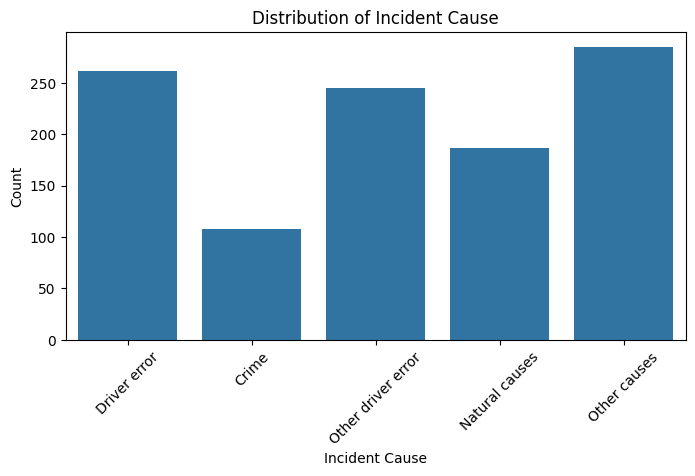

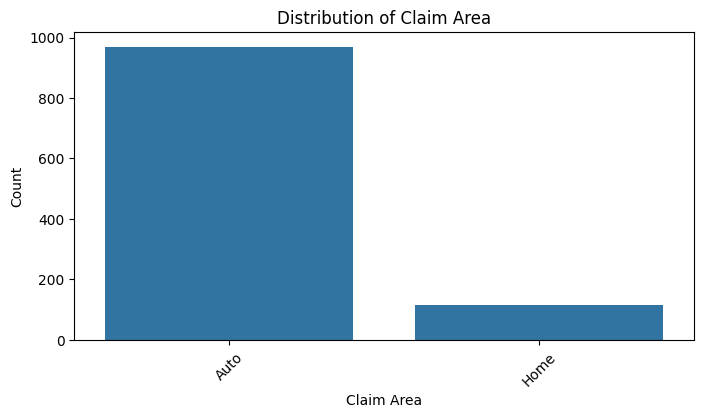

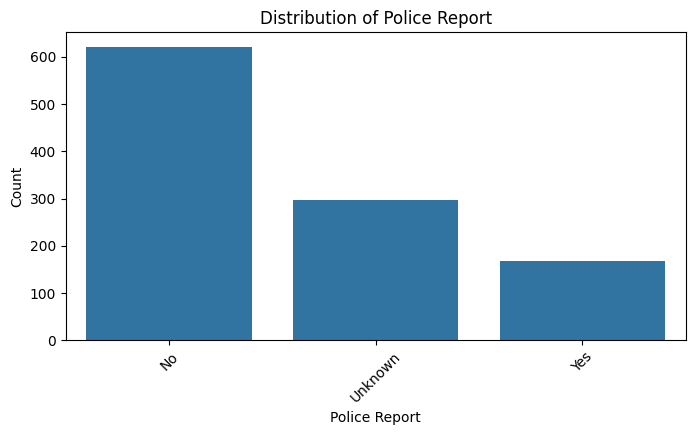

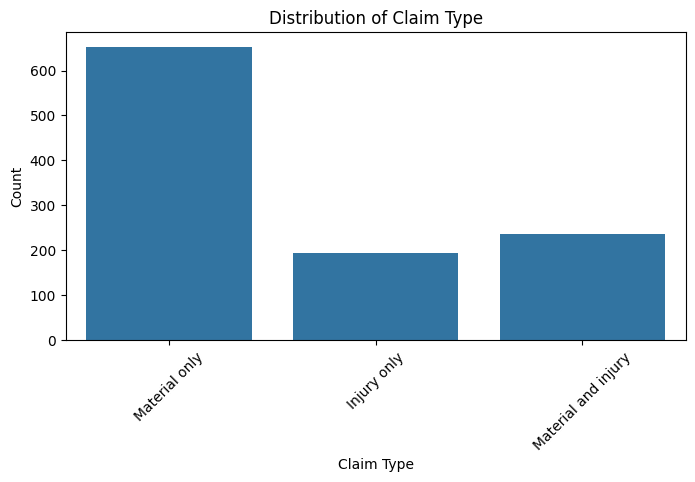

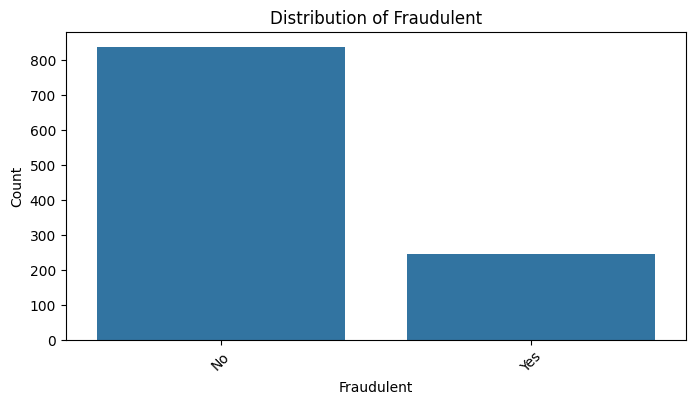

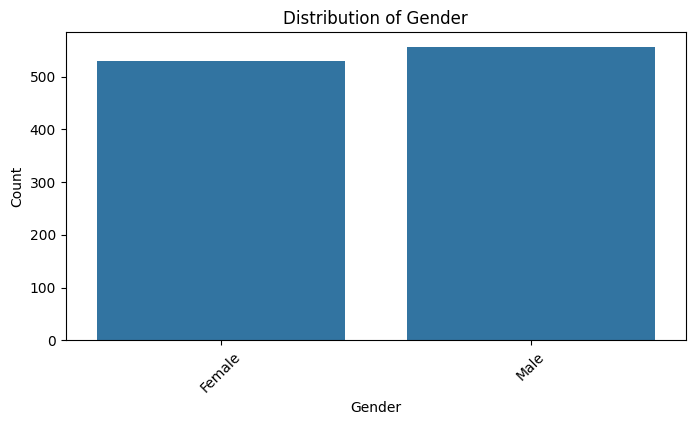

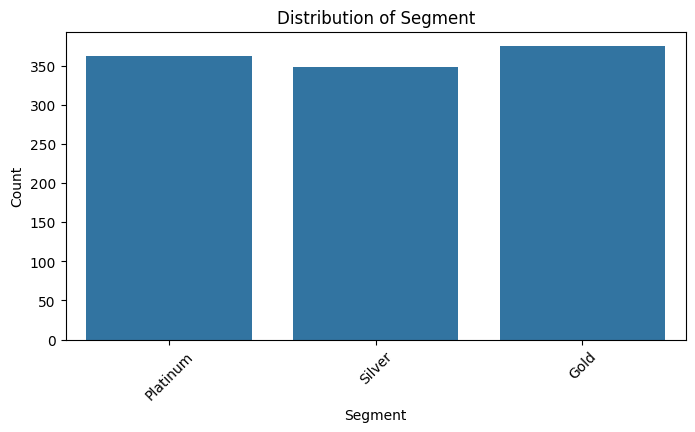

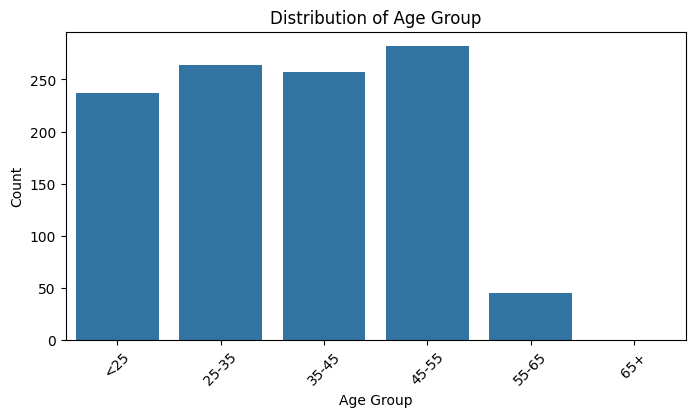

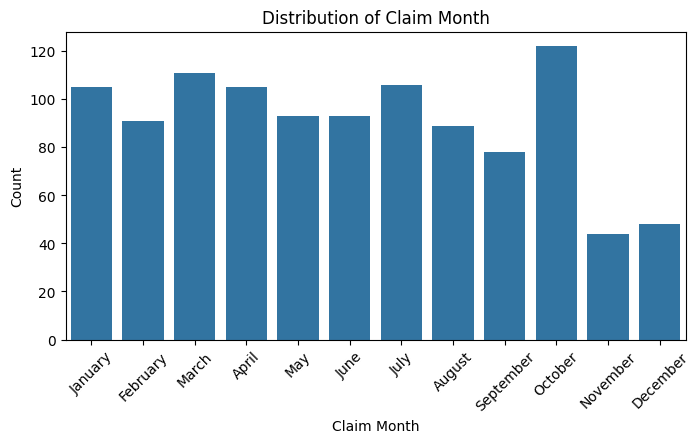

In [52]:
age_order = ['<25', '25-35', '35-45', '45-55', '55-65', '65+']

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

for i in ['incident_cause', 'claim_area', 'police_report', 'claim_type', 'fraudulent', 'gender', 'segment','age_group', 'claim_month']:
    plt.figure(figsize=(8,4))
    if i == 'age_group':
        sns.countplot(data=insurance_df, x=i, order=age_order)

    elif i == 'claim_month':
        sns.countplot(data=insurance_df, x=i, order=month_order)

    else:
        sns.countplot(data=insurance_df, x=i)
    
    plt.title(f"Distribution of {i.replace('_', ' ').title()}")
    plt.xlabel(f"{i.replace('_',' ').title()}")
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

##### Observations

- Auto insurance accounts for the overwhelming majority of claims, indicating that subsequent fraud patterns are likely to be primarily influenced by the auto insurance portfolio.
- Material-only claims represent the largest claim category, suggesting that property damage claims constitute the most common type of insurance loss within the dataset.
- Fraudulent claims account for approximately one-fourth of the portfolio, providing sufficient representation for meaningful comparative analysis between fraudulent and legitimate claims.
- Most claims are submitted without a police report, while a notable proportion have an unknown reporting status. This variable may therefore provide useful insights when investigating fraud patterns.
- Customer records are reasonably balanced across gender and customer segments, reducing the likelihood that subsequent analyses are disproportionately influenced by a single demographic group.
- Incident causes are distributed across multiple categories, enabling meaningful comparison of fraud rates and claim characteristics across different incident types in later analyses.
-  Insurance claims are predominantly concentrated among policyholders aged 25–55 years, indicating that the portfolio is primarily driven by working-age customers. This provides sufficient representation to assess whether fraud risk varies across different age segments in subsequent analyses.
- Claim volumes remain relatively consistent throughout the year, with no evidence of pronounced seasonality or unusually high claim concentration in any specific month. This suggests that temporal variations in fraud, if observed later, are more likely to reflect behavioral differences rather than fluctuations in overall claim frequency.

### Bivariate Analysis

This section explores relationships between customer demographics, claim characteristics, and fraudulent claim behaviour to identify the factors most strongly associated with insurance fraud.

#### Fraud Analysis

In [53]:
# Fraud Overview

pd.DataFrame({'Metric':['Fraudulent Claims', 'Non-Fraudulent Claims', 'Fraud Rate (%)'],\
              'Value':[(insurance_df.fraudulent=='Yes').sum(), (insurance_df.fraudulent=='No').sum(),\
                       round((insurance_df.fraudulent=='Yes').mean()*100,2)]})

,Metric,Value
0,Fraudulent Claims,247.00
1,Non-Fraudulent Claims,838.00
2,Fraud Rate (%),22.76


##### Observations

- Approximately one-fourth of all insurance claims are identified as fraudulent, indicating that fraud represents a significant operational concern rather than isolated events.
- The sizeable proportion of fraudulent claims provides sufficient representation for identifying customer and claim characteristics associated with elevated fraud risk.

#### Fraud Analysis across Categorical Variables

Fraud rates are compared across customer demographics and claim characteristics to identify categorical factors associated with a higher likelihood of fraudulent claims.

In [54]:
for i in ['incident_cause', 'claim_area', 'police_report', 'claim_type', 'gender', 'state', 'segment', 'age_group', 'claim_month']:

    print(f"\nFraud Analysis by {i.replace('_', ' ').title()} (%)\n")

    fraud_table = round(pd.crosstab(index=insurance_df[i], columns=insurance_df['fraudulent'], normalize='index') * 100, 2)

    if i == 'age_group':
        fraud_table = fraud_table.reindex(age_order)

    elif i == 'claim_month':
        fraud_table = fraud_table.reindex(month_order)

    display(fraud_table)


Fraud Analysis by Incident Cause (%)



fraudulent,No,Yes
incident_cause,,
Crime,75.93,24.07
Driver error,77.39,22.61
Natural causes,79.03,20.97
Other causes,75.09,24.91
Other driver error,78.78,21.22



Fraud Analysis by Claim Area (%)



fraudulent,No,Yes
claim_area,,
Auto,76.91,23.09
Home,80.00,20.00



Fraud Analysis by Police Report (%)



...

fraudulent,No,Yes
segment,,
Gold,78.40,21.60
Platinum,76.52,23.48
Silver,76.72,23.28



Fraud Analysis by Age Group (%)



fraudulent,No,Yes
age_group,,
<25,79.75,20.25
25-35,78.41,21.59
35-45,76.26,23.74
45-55,75.18,24.82
55-65,75.56,24.44
65+,NaN,NaN



Fraud Analysis by Claim Month (%)



fraudulent,No,Yes
claim_month,,
January,78.10,21.90
February,75.82,24.18
March,72.07,27.93
April,81.90,18.10
May,77.42,22.58
June,78.49,21.51
July,77.36,22.64
August,76.40,23.60
September,76.92,23.08


##### Observations

- Police report status exhibits the strongest association with fraudulent claims. Claims with an unknown police report status have the highest fraud rate (27.36%), whereas claims accompanied by a confirmed police report show a substantially lower fraud rate (9.52%). This suggests that supporting documentation may be an important indicator during fraud screening.
- Fraud rates vary across claim types, with material-related claims exhibiting greater fraud prevalence than injury-only claims. Injury-only claims record the lowest fraud rate (14.36%), while claims involving material damage show fraud rates exceeding 24%, indicating that claim type may serve as a useful fraud risk indicator.
- Fraud occurrence increases gradually across age groups, rising from approximately 20% among policyholders below 25 years to over 26% for customers aged 55–65 years. Although the increase is moderate, it suggests that age may contribute to fraud risk when evaluated alongside other claim characteristics.
- Fraud rates remain relatively consistent across gender, customer segment, incident cause, and claim area, indicating that these variables individually possess limited discriminatory power for identifying fraudulent claims.
- State-level fraud rates exhibit considerable variation; however, these findings should be interpreted cautiously because several states contain relatively few observations, making the estimated fraud rates sensitive to small sample sizes.
- No pronounced seasonal pattern is observed in fraud occurrence across claim months. Although November records the highest fraud rate (29.55%) and December the lowest (14.58%), fraud remains relatively stable throughout most months, suggesting that seasonality is unlikely to be a primary driver of fraudulent behaviour.

#### Key Fraud Drivers

The categorical analysis identified several variables exhibiting notable differences in fraud rates. These key fraud drivers are visualized below to facilitate comparison and highlight the factors most strongly associated with fraudulent claim behaviour.

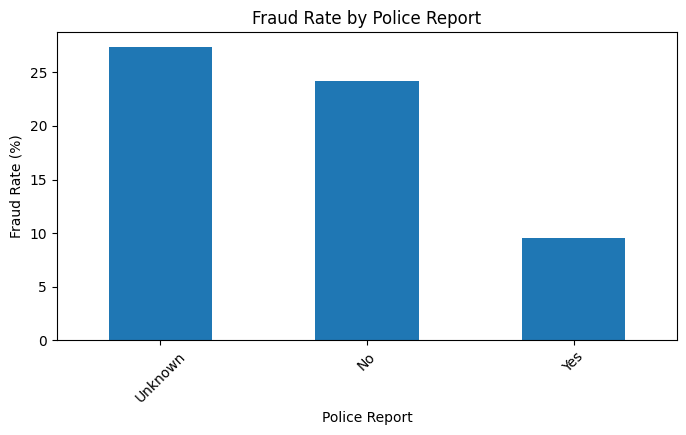

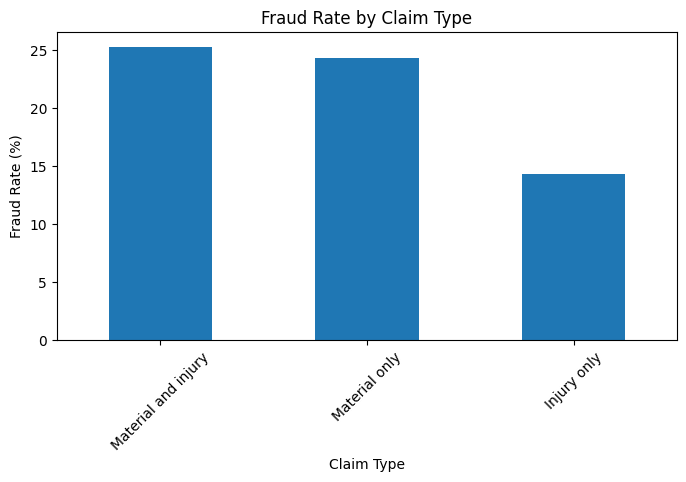

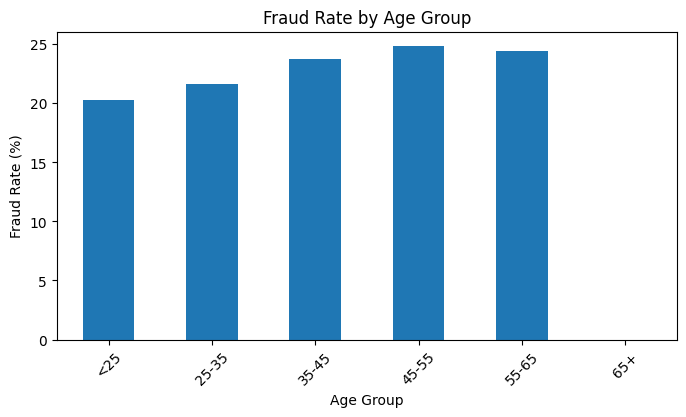

In [55]:
for i in ['police_report', 'claim_type', 'age_group']:

    fraud_rate = pd.crosstab(index=insurance_df[i],columns=insurance_df['fraudulent'],normalize='index') * 100

    if i == 'age_group':
        fraud_rate = fraud_rate.reindex(age_order)
        fraud_rate['Yes'].plot(kind='bar', figsize=(8,4))
    else:
        fraud_rate['Yes'].sort_values(ascending=False).plot(kind='bar', figsize=(8,4))

    plt.title(f"Fraud Rate by {i.replace('_', ' ').title()}")
    plt.xlabel(i.replace('_', ' ').title())
    plt.ylabel('Fraud Rate (%)')
    plt.xticks(rotation=45)
    print('\n')
    plt.show()

##### Observations

- The visual analysis validates the patterns identified in the cross-tab analysis and confirms police report status, claim type, and age group as the primary fraud-related variables.
- These variables warrant further statistical validation and can serve as potential predictors in fraud risk assessment.

#### Fraud Analysis across Numerical Variables

The numerical characteristics of fraudulent and non-fraudulent claims are compared using summary statistics to evaluate whether fraud is associated with differences in claim value, customer age, or historical claim activity.

#### Comparative Summary Statistics

In [56]:
insurance_df.groupby('fraudulent')[['claim_amount', 'total_policy_claims', 'age']].agg(['mean','median'])

claim_amount         total_policy_claims               age       
                    mean  median                mean median       mean median
fraudulent                                                                   
No          11746.133652  2740.0            1.535800    1.0  36.960621   37.0
Yes         12355.769231  2740.0            1.736842    1.0  38.068826   38.0

##### Observations

- Fraudulent claims exhibit slightly higher average claim amounts and a greater average number of previous policy claims than non-fraudulent claims, suggesting a potential relationship between claim history and fraudulent behaviour.
- Fraudulent policyholders are marginally older on average, reinforcing the gradual increase in fraud rates observed across the age-group analysis.
- Median claim amounts and median policy claim counts remain largely comparable across both groups, indicating that the observed differences in averages are influenced by a relatively small number of high-value claims and customers with unusually frequent claim histories.

#### Distribution of Numerical Variables by Fraud Status

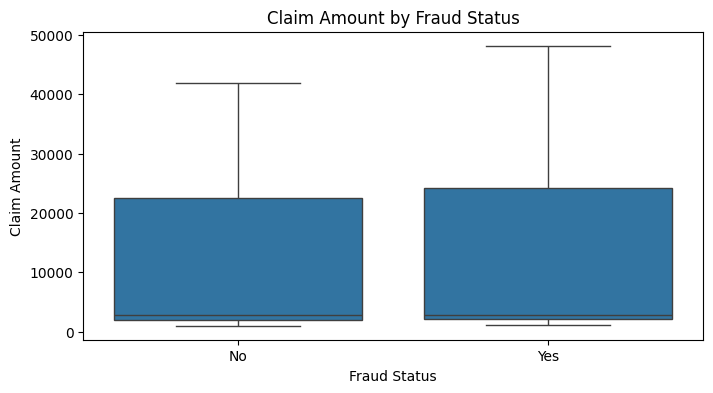

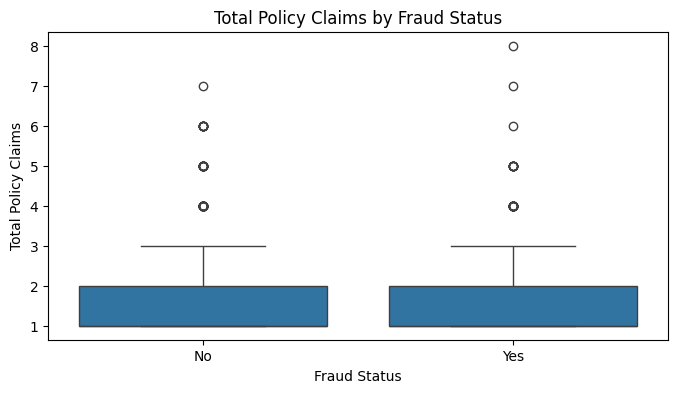

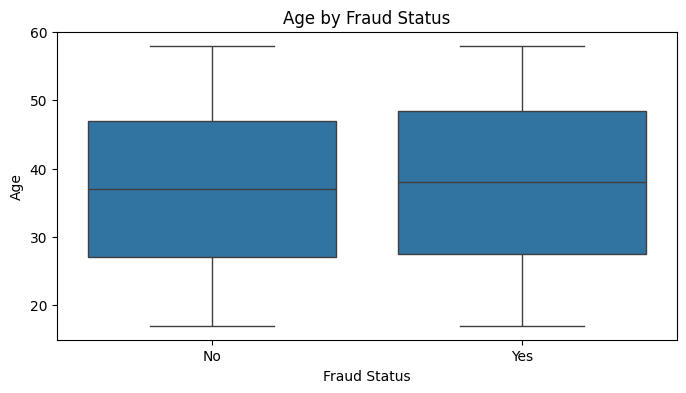

In [57]:
for i in cont_df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=insurance_df, x='fraudulent', y=i)
    plt.title(f"{i.replace('_',' ').title()} by Fraud Status")
    plt.xlabel('Fraud Status')
    plt.ylabel(i.replace('_',' ').title())
    plt.show()

##### Observations

- The boxplots indicate substantial overlap in the distributions of claim amount, previous policy claims, and customer age across fraudulent and non-fraudulent claims, suggesting that these numerical variables alone provide limited discriminatory power for fraud detection.
- Fraudulent claims exhibit slightly greater variability in claim amounts and previous policy claims, with a higher concentration of extreme observations contributing to the differences observed in the summary statistics.
- The median values remain similar across fraud categories, visually confirming that the higher average values are primarily influenced by a relatively small number of high-value claims and customers with frequent claim histories.
- Compared with the categorical analysis, numerical variables demonstrate weaker separation between fraudulent and legitimate claims, indicating that fraud appears to be driven more by claim characteristics than by numerical attributes alone.

#### Claim Amount Analysis

This section examines how claim amounts vary across different claim characteristics to identify the factors associated with higher insurance payouts. Understanding these patterns helps insurers recognize claim scenarios that may require closer financial scrutiny.

#### Distribution of Claim Amount across Categories

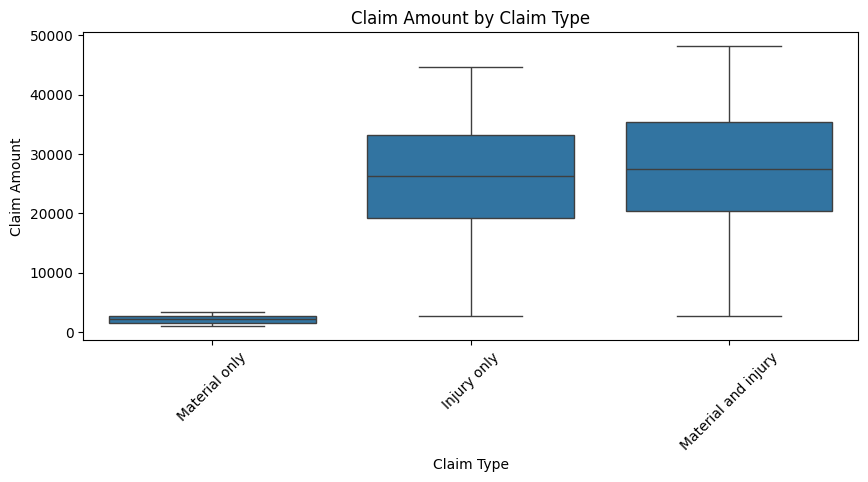

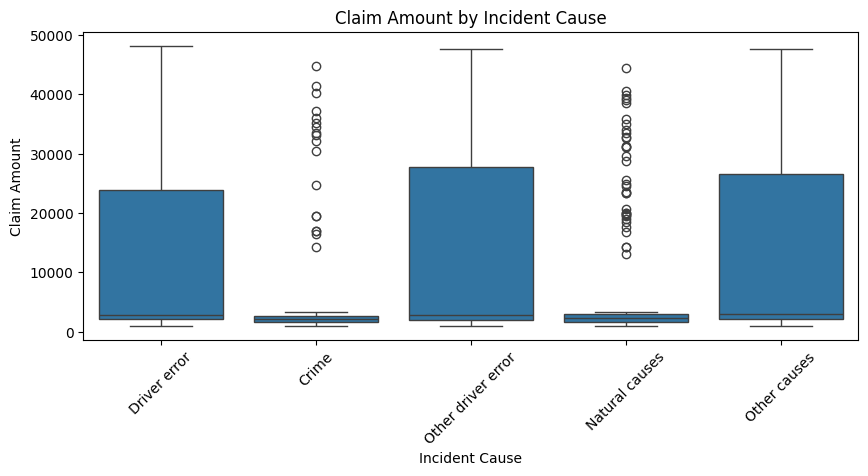

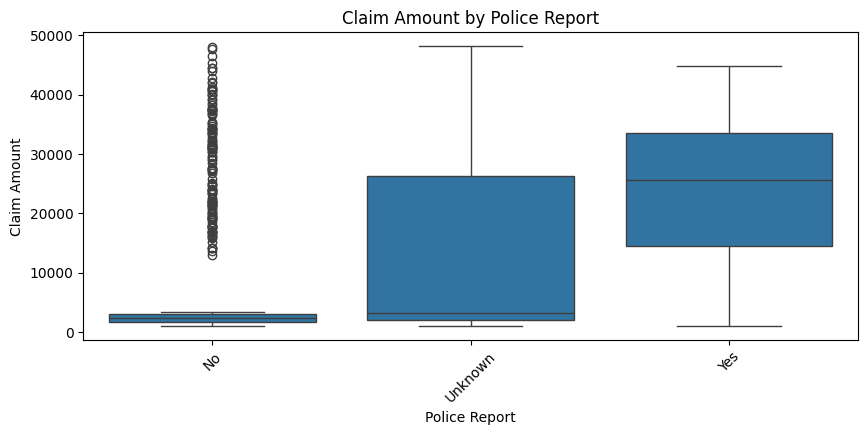

In [58]:
for i in ['claim_type', 'incident_cause', 'police_report']:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=insurance_df, x=i, y='claim_amount')
    plt.title(f"Claim Amount by {i.replace('_',' ').title()}")
    plt.xlabel(i.replace('_',' ').title())
    plt.ylabel('Claim Amount')
    plt.xticks(rotation=45)
    plt.show()

##### Observations

- Claim type has the strongest influence on claim severity. Material-only claims are consistently associated with substantially lower claim amounts, whereas claims involving injuries (either injury-only or material-and-injury) exhibit considerably higher median payouts and wider variability. This indicates that injury-related claims represent the insurer's greatest financial exposure.
- Claim amount varies noticeably across incident causes, with driver-related incidents and other non-crime causes displaying broader distributions and higher-value claims. In contrast, crime and natural-cause claims are generally associated with lower claim amounts, although a few extreme cases indicate occasional high-cost events.
- Claims supported by a police report tend to involve significantly higher claim amounts than claims without a police report. This suggests that police reports are more commonly associated with severe incidents requiring larger settlements, while lower-value claims are often resolved without formal police involvement.
- Several categories exhibit extreme high-value claims and substantial variability, indicating that a relatively small number of costly claims contribute disproportionately to overall claim expenditure. These observations highlight the importance of monitoring high-severity claims as part of financial risk management.
- The considerable overlap in claim amount distributions across categories suggests that claim amount alone is unlikely to distinguish claim characteristics or fraudulent behaviour. Consequently, claim amount should be evaluated alongside other customer and claim-related attributes during fraud investigation and risk assessment.

### Correlation Analysis

The objective of this section is to examine the relationships among numerical variables and identify whether customer age, historical claim frequency, and claim amount exhibit meaningful linear associations. Understanding these relationships helps determine whether changes in one variable are accompanied by changes in another and provides additional context for subsequent statistical analysis.

In [59]:
corr=cont_df.corr(numeric_only=True).round(2)
corr

,claim_amount,total_policy_claims,age
claim_amount,1.00,-0.02,0.00
total_policy_claims,-0.02,1.00,-0.02
age,0.00,-0.02,1.00


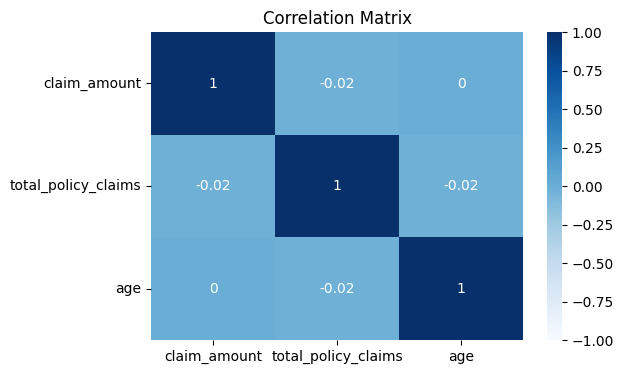

In [60]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

##### Observations

- The numerical variables exhibit negligible linear correlations, with all pairwise correlation coefficients close to zero. This indicates that customer age, historical claim frequency, and claim amount vary largely independently of one another.
- Claim amount shows almost no relationship with previous policy claims (r = -0.02), suggesting that customers with a greater history of claims do not necessarily submit higher-value claims. Claim frequency and claim severity therefore appear to represent distinct dimensions of insurance risk.
- Customer age is essentially uncorrelated with both claim amount and previous claim history, indicating that age alone is unlikely to be a meaningful predictor of claim severity or historical claim behaviour.
- The absence of strong linear relationships reinforces the findings from the earlier bivariate analysis, where categorical variables such as police report status and claim type demonstrated a much stronger association with fraudulent claims than the numerical variables.
- From a business perspective, fraud detection and risk assessment should rely on a combination of claim characteristics and customer attributes rather than numerical variables alone, as the latter provide limited explanatory power when considered independently.

### Hypothesis Testing

The exploratory analysis identified several patterns that appeared to be associated with fraudulent claims. This section statistically validates these observations using appropriate hypothesis tests to determine whether the observed relationships are statistically significant and can be generalized beyond this data.

#### Association between Police Report Status and Fraud

Objective: To determine whether police report status is significantly associated with fraudulent insurance claims.

**Null Hypothesis (H₀):**

Police report status and fraudulent claims are independent.

**Alternative Hypothesis (H₁):**

Police report status and fraudulent claims are associated.

In [61]:
result= stats.chi2_contingency(pd.crosstab(insurance_df.police_report,insurance_df.fraudulent))

print(f"P-value: {result.pvalue:.5f}")

P-value: 0.00003


In [62]:
alpha = 0.05

if result.pvalue < alpha:
    print("Reject the Null Hypothesis (H₀)")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")

Reject the Null Hypothesis (H₀)


##### Interpretation

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.

There is sufficient statistical evidence to conclude that police report status is significantly associated with fraudulent claims. This validates the pattern identified during the exploratory analysis and suggests that police report status should be considered an important indicator when prioritizing fraud investigations.

#### Association between Claim Type and Fraud

Objective: To determine whether claim type is significantly associated with insurance fraud.

**Null Hypothesis (H₀):**

Claim type and fraudulent claims are independent.

**Alternative Hypothesis (H₁):**

Claim type and fraudulent claims are associated.

In [63]:
result1 = stats.chi2_contingency(pd.crosstab(insurance_df.claim_type,insurance_df.fraudulent))

print(f"P-value: {result1.pvalue:.5f}")

P-value: 0.00804


In [64]:
alpha = 0.05

if result1.pvalue < alpha:
    print("Reject the Null Hypothesis (H₀)")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")

Reject the Null Hypothesis (H₀)


##### Interpretation

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.

There is sufficient statistical evidence to conclude that claim type is significantly associated with insurance fraud. This validates the exploratory analysis, which indicated that material-related claims exhibit higher fraud rates than injury-only claims. Consequently, claim type can serve as a valuable feature when assessing the fraud risk of incoming insurance claims.

#### Association between Age Group and Fraud

Objective: To determine whether age group is significantly associated with insurance fraud.

**Null Hypothesis (H₀):**

Age group and fraudulent claims are independent.

**Alternative Hypothesis (H₁):**

Age group and fraudulent claims are associated.

In [65]:
result2 = stats.chi2_contingency(pd.crosstab(insurance_df.age_group,insurance_df.fraudulent))

print(f"P-value: {result2.pvalue:.5f}")

P-value: 0.74562


In [66]:
alpha = 0.05

if result2.pvalue < alpha:
    print("Reject the Null Hypothesis (H₀)")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")

Fail to Reject the Null Hypothesis (H₀)


##### Interpretation

Since the p-value is greater than the significance level of 0.05, the null hypothesis cannot be rejected.

There is insufficient statistical evidence to conclude that age group is significantly associated with insurance fraud. Although the exploratory analysis suggested a gradual increase in fraud rates across older age groups, the observed differences are not statistically significant and may be attributable to random variation within the dataset.

This indicates that age group, when considered independently, is not a reliable indicator of fraudulent behaviour and should not be prioritized as a standalone factor in fraud detection.

### Key Business Insights

- Fraudulent claims account for approximately 23% of the claims portfolio, highlighting fraud as a significant operational concern.
- Police report status is the strongest fraud-related indicator. Claims with an unknown police report status exhibit substantially higher fraud rates, and this relationship is statistically significant.
- Claim type is significantly associated with fraud. Material-related claims show higher fraud prevalence than injury-only claims, suggesting that claim characteristics are valuable predictors of fraud risk.
- Although exploratory analysis suggested that fraud rates increase with age, hypothesis testing found no statistically significant association between age group and fraud. Customer age alone should therefore not be used as a primary fraud indicator.
- Claim amounts are highly right-skewed, with a small number of high-value claims contributing disproportionately to financial exposure.
- Numerical variables demonstrate weak linear relationships, indicating that fraud detection should rely more on claim characteristics than on customer age or historical claim counts alone.

### Business Recommendations

- Prioritize manual review for claims with unknown police report status, as these exhibit significantly higher fraud rates.
- Incorporate claim type into fraud risk scoring models to improve the identification of potentially fraudulent claims.
- Develop rule-based alerts that combine multiple high-risk characteristics instead of relying on a single variable.
- Allocate investigation resources based on statistically validated fraud indicators rather than customer demographics alone.
- Continue monitoring high-value claims due to their financial impact, even though claim amount by itself was not established as a primary fraud indicator.